In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../Data/Train.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
np.random.seed(42)
df['Order_Hour'] = np.random.randint(0, 24, df.shape[0])
df[['Order_Hour']].head()

,Order_Hour
0,6
1,19
2,14
3,10
4,7


In [4]:
df['Hour_sin'] = np.sin(2 * np.pi * df['Order_Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Order_Hour'] / 24)
df[['Order_Hour','Hour_sin','Hour_cos']].head()

,Order_Hour,Hour_sin,Hour_cos
0,6,1.000000,6.123234e-17
1,19,-0.965926,2.588190e-01
2,14,-0.500000,-8.660254e-01
3,10,0.500000,-8.660254e-01
4,7,0.965926,-2.588190e-01


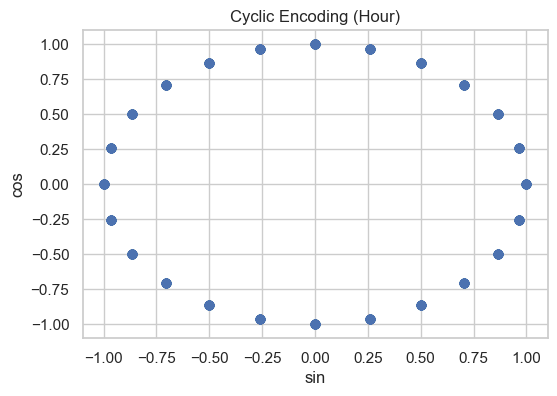

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(df['Hour_sin'], df['Hour_cos'], alpha=0.5)
plt.title("Cyclic Encoding (Hour)")
plt.xlabel("sin")
plt.ylabel("cos")
plt.show()

In [7]:
df['Cost_Bin_Width'] = pd.cut(df['Cost_of_the_Product'], bins=4)
df[['Cost_of_the_Product','Cost_Bin_Width']].head()

,Cost_of_the_Product,Cost_Bin_Width
0,306,"(254.25, 309.0]"
1,114,"(89.781, 144.75]"
2,215,"(199.5, 254.25]"
3,126,"(89.781, 144.75]"
4,113,"(89.781, 144.75]"


In [8]:
df['Cost_Bin_Freq'] = pd.qcut(df['Cost_of_the_Product'], q=4)

df[['Cost_of_the_Product','Cost_Bin_Freq']].head()

,Cost_of_the_Product,Cost_Bin_Freq
0,306,"(254.0, 309.0]"
1,114,"(89.999, 146.0]"
2,215,"(202.5, 254.0]"
3,126,"(89.999, 146.0]"
4,113,"(89.999, 146.0]"


In [9]:
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df['Cost_Bin_KBins'] = kbd.fit_transform(
    df[['Cost_of_the_Product']]
)
df[['Cost_of_the_Product','Cost_Bin_KBins']].head()

,Cost_of_the_Product,Cost_Bin_KBins
0,306,3.0
1,114,0.0
2,215,2.0
3,126,0.0
4,113,0.0


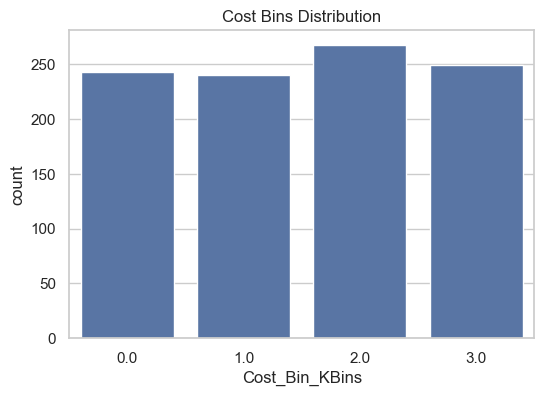

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cost_Bin_KBins', data=df)
plt.title("Cost Bins Distribution")
plt.show()